### Survival Analysis
This file calls the classes and functions declared in survival_analysis.py to fit survival analysis models

The convention used in this file is:
<ul>
    <li>'um': linear perp</li>
    <li>'cm': inverse perp</li>
</ul>

### Parametric Functions

To Do:
- research factors that would affect absorption time
- consider regression results from papers?
- consider limit order variables

To be investigated:
- funding rate
- volatility
- market volumes (spot and perp)
- shock size?

From BitMex paper:
- relative spread (average spread of spot divided by perp spread)
- relative trading volume (total trading volume of spot divided by perp)
- log return (for spot and perp)
- absolute basis (absolute value of average difference of log prices between spot and perp)
- dummy variable for days with negative return, interaction with absolute basis

From limit order paper:
- bid-ask spread, liquidity, volatility, share price, daily volume

From crypto carry paper:
- index for google searches
- crypto returns over past day/week/month
- signed trading volume (volume x returns)

Aggregated variables: (daily)
- spread and relative spread
- trading volume and relative trading volume
- log return for spot and perp (lagged day/week/month)
- absolute basis
- volatility
- index for google searches
- market status?
- indicator for positive/negative return?
- funding rate

It's expected that convergence patterns should be affected by crypto market efficiency in general

Idea:
- pick one convergence/shock combination
- join to covariates (daily)
- fit mixed cox model and parametric models (exponential?)

In [1]:
import datetime
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
from trade_data_pull import *
from survival_analysis import *

#### Kaplan-Meier Plots

In [ ]:
# spot POV (spot to perps)
sa = SurvivalAnalysis('BTCUSDT', 'Binance', 'um')
data_sp, events_sp, shocks_sp = sa.fit_KM('20251201', '20251231', [0.001])

Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
lee_mykland 3.0 0.99 None 0.0010000000000000009 True spot


In [ ]:
# perp POV (perps to spot)
data_ps, events_ps, shocks_ps = sa.fit_KM('20251201', '20251231', [0.001], first='perp')

Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
lee_mykland 3.0 0.99 None 0.0010000000000000009 True perp


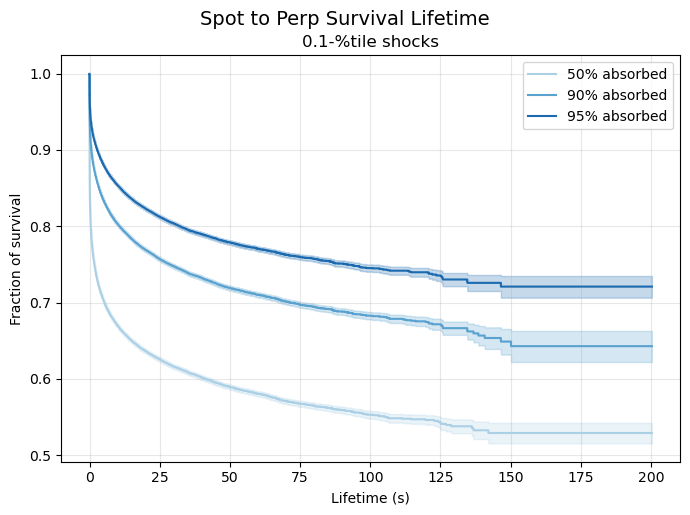

In [6]:
kmfs = sa.graph_results(shocks_sp, [0.001], ncols=1, figsize=(7,5), first='spot')

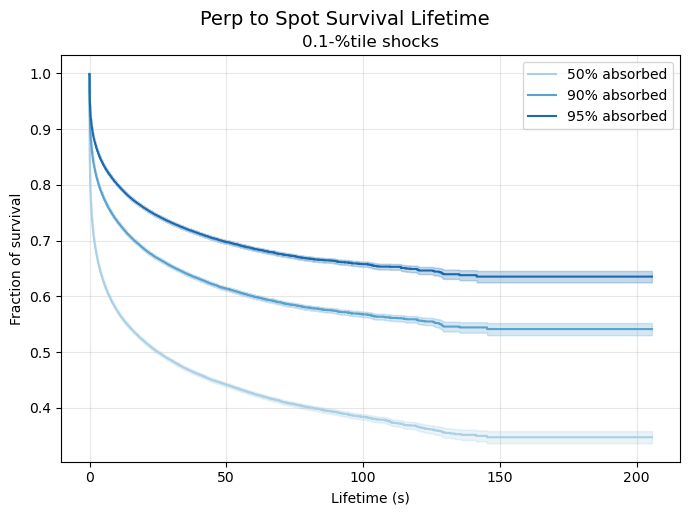

In [11]:
kmfs = sa.graph_results(shocks_ps, [0.001], ncols=1, figsize=(7,5), first='perp')

In [3]:
# sa = SurvivalAnalysis('BTCUSDT')
# # df_ret_joined contains funding rates
# data, df_ret_joined = sa._get_and_parse_data('20210101', '20210201')

Fetching file list from Binance...
Processing 32 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Using cached file list...
Processing 32 files...
Processing batch 1/2
Processing batch 2/2
Combining results...


#### Grabbing Covariates

Finding spread and basis

In [3]:
spots_bidask = data.to_intervals_bidask(data.df_trades_spots, '1s').to_pandas().set_index('timestamp_bin')
spots_bidask['spread_spot'] = spots_bidask['ask_price'] - spots_bidask['bid_price']

perps_bidask = data.to_intervals_bidask(data.df_trades_perps, '1s').to_pandas().set_index('timestamp_bin')
perps_bidask['spread_perp'] = perps_bidask['ask_price'] - perps_bidask['bid_price']

In [4]:
bidask = spots_bidask.merge(perps_bidask, how='inner', left_index=True, right_index=True, suffixes=['_spot', '_perp']).dropna()
bidask['midpoint_spot'] = (bidask['ask_price_spot'] + bidask['bid_price_spot'])/2
bidask['midpoint_perp'] = (bidask['ask_price_perp'] + bidask['bid_price_perp'])/2
bidask['basis'] = bidask['midpoint_perp'] - bidask['midpoint_spot']
bidask['spread_spot'] = bidask['spread_spot']/bidask['midpoint_spot']*10000
bidask['spread_perp'] = bidask['spread_perp']/bidask['midpoint_perp']*10000
bidask['basis'] = bidask['basis']/bidask['midpoint_spot']*10000
bidask = bidask.reset_index()

In [5]:
# aggregated by day
bidask["date"] = pd.to_datetime(bidask['timestamp_bin']).dt.date

bidask =  bidask.merge(
    bidask
    .groupby("date")[["spread_spot", 'spread_perp', 'basis']]
    .mean().reset_index().rename(columns={'spread_spot':'spread_spot_avg','spread_perp':'spread_perp_avg', 'basis':'basis_avg'}), how='outer', on='date'
)

In [6]:
spread_basis_daily = bidask[['date', 'spread_spot_avg', 'spread_perp_avg', 'basis_avg']].drop_duplicates().set_index('date')

Trade volume

In [7]:
data.convert_tz = None

In [8]:
spot_volume = data.get_klines('20210101', '20210201', 'spot', '1d', columns=["Open time", "Close time", 'Open', "Close", "log_return", 'Volume'])
perp_volume = data.get_klines('20210101', '20210201', 'perp', '1d', columns=["Open time", "Close time", 'Open', "Close", "log_return", 'Volume'])

In [9]:
spot_volume_daily = spot_volume.rename(columns={'Open time':'date','Volume':'volume'})[['date','volume']].set_index('date')

Funding fees (8H)

In [10]:
funding = data.get_funding_data('20210101', '20210201')

In [11]:
funding["date"] = pd.to_datetime(funding["fundingTime"]).dt.date

daily_avg = (
    funding
    .groupby("date")["fundingRate"]
    .mean()
)

Google search index

In [12]:
from pytrends.request import TrendReq
import pandas as pd

pytrends = TrendReq(hl='en-US', tz=0)

pytrends.build_payload(
    kw_list=["Bitcoin"],
    timeframe="2021-01-01 2026-01-01",
    geo=""
)

data = pytrends.interest_over_time()
google_sentiment = data[["Bitcoin"]]


<Axes: xlabel='date'>

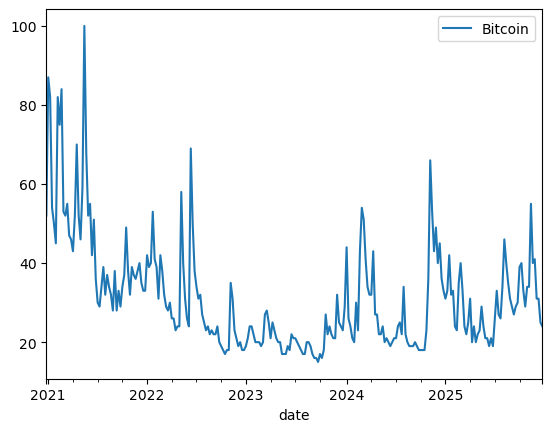

In [59]:
google_sentiment.plot()

In [13]:
import requests
import pandas as pd
from urllib.parse import quote

def wiki_pageviews(page_title: str, start="20210101", end="20260101"):
    page = quote(page_title, safe="")
    url = f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/{page}/daily/{start}/{end}"

    headers = {
        "User-Agent": "JuliaHuang-Thesis/1.0 (contact: ydj.huang@mail.utoronto.ca)"
    }

    resp = requests.get(url, headers=headers, timeout=30)
    print("status:", resp.status_code, "content-type:", resp.headers.get("content-type"))

    resp.raise_for_status()
    r = resp.json()

    df = pd.DataFrame({
        "date": [pd.to_datetime(it["timestamp"][:8]) for it in r["items"]],
        "views": [it["views"] for it in r["items"]],
    })
    return df

wikipedia_views = wiki_pageviews("Bitcoin").set_index('date')


status: 200 content-type: application/json; charset=utf-8


Market status (fear and greed)

In [14]:
import requests
import pandas as pd

url = "https://api.alternative.me/fng/?limit=0"  # 0 = all available history
resp = requests.get(url)
resp_data = resp.json()["data"]

market_status = pd.DataFrame(resp_data)

# convert types
market_status["date"] = pd.to_datetime(market_status["timestamp"].astype(int), unit="s")
market_status["fear_greed"] = market_status["value"].astype(int)

# keep just what you need
market_status = market_status[["date", "fear_greed", "value_classification"]]

market_status.sort_values("date", inplace=True)
market_status.reset_index(drop=True, inplace=True)
market_status = market_status.set_index('date')

market_status.head()


,fear_greed,value_classification
date,,
2018-02-01,30,Fear
2018-02-02,15,Extreme Fear
2018-02-03,40,Fear
2018-02-04,24,Extreme Fear
2018-02-05,11,Extreme Fear


Volatility

In [45]:
def get_iv(source, start, end, instr='BTC', resolution=1):
    """
    source = ['block', 'deribit']
    """
    start = datetime.datetime.strptime(start, '%Y%m%d')
    end = datetime.datetime.strptime(end, '%Y%m%d')

    if source == 'block':
        r = requests.get('https://www.theblock.co/api/charts/chart/crypto-markets/options/btc-atm-implied-volatility')
        series_names = r.json()['chart']['jsonFile']['Series'].keys()

        df_vols = []
        for s in series_names:
            df_vol = pd.DataFrame(r.json()['chart']['jsonFile']['Series'][s]['Data'])
            df_vol['duration'] = s
            df_vols.append(df_vol)

        iv_block = pd.concat(df_vols)
        iv_block['Timestamp'] = iv_block['Timestamp'].apply(lambda x: datetime.datetime.fromtimestamp(x))
        iv_block['day'] = iv_block['Timestamp'].apply(lambda x: x.date())
        iv_block = iv_block[(iv_block['day'] >= start.date()) & (iv_block['day'] <= end.date())]
        return iv_block.set_index('Timestamp')
    elif source == 'deribit':
        base_url = "https://www.deribit.com/api/v2/public/get_volatility_index_data"

        if start is None:
            start = datetime.datetime.now(datetime.timezone.utc) - datetime.timedelta(days=7)
        if end is None:
            end = datetime.datetime.now(datetime.timezone.utc)

        # Calculate chunk size based on resolution
        # For hourly data, ~1000 points = ~41 days
        points_per_request = 1000
        seconds_per_chunk = points_per_request * resolution
        chunk_duration = datetime.timedelta(seconds=seconds_per_chunk)

        all_data = []
        current_start = start

        while current_start < end:
            current_end = min(current_start + chunk_duration, end)
            
            start_ts = int(current_start.timestamp() * 1000)
            end_ts = int(current_end.timestamp() * 1000)

            params = {
                "currency": instr.upper(),
                "resolution": resolution,
                "start_timestamp": start_ts,
                "end_timestamp": end_ts,
            }

            r = requests.get(base_url, params=params)
            if r.status_code != 200:
                raise RuntimeError(f"Deribit API error: {r.status_code} {r.text}")

            result = r.json().get("result", {})
            data_values = result.get("data", [])
            
            if data_values:
                all_data.extend(data_values)
                print(f"Fetched {len(data_values)} records for {current_start.date()} to {current_end.date()}. Total: {len(all_data)}")
            
            current_start = current_end

        if not all_data:
            print("⚠️ No data returned. Check your date range or resolution.")
            return pl.DataFrame()

        print(f"Total records fetched: {len(all_data)}")

        # Data format: [timestamp, open, high, low, close]
        df_vol = pl.DataFrame(
            all_data,
            schema=["timestamp", "open", "high", "low", "close"],
            strict=False
        )
        
        # Use close as the IV value
        df_vol = df_vol.select([
            pl.col("timestamp"),
            pl.col("close").alias("iv")
        ])

        # Convert timestamp to datetime (UTC)
        df_vol = df_vol.with_columns(
            pl.col("timestamp").cast(pl.Datetime("ms"))
        )

        df_vol = df_vol.with_columns(
            pl.col("timestamp")
            .dt.replace_time_zone(None)
        )

        # Remove duplicates that might occur at chunk boundaries
        df_vol = df_vol.unique(subset=["timestamp"])

        return df_vol.sort("timestamp").to_pandas()
    
def aggregate_vol(df_vol_klines, period, drop_incomplete=True):

    if period == '1H':
        return df_vol_klines[['Close time', 'realized_vol']].set_index('Close time')
    ann_factor = 1 #np.sqrt(365 * 24)
    agg_vol = df_vol_klines.set_index('Close time').rolling(window=period)["log_return"].std(ddof=0).reset_index().rename(columns={'log_return': 'realized_vol'}).set_index('Close time') * ann_factor
    
    if drop_incomplete:
        agg_vol.loc[:agg_vol.index[0] + pd.Timedelta(period)] = np.nan
        agg_vol = agg_vol.dropna()

    return agg_vol

In [57]:
vol = get_iv('block', '20210101', '20210201')
vol = vol[vol['duration']=='ATM 7']

In [58]:
vol = vol[['day', 'Result']].rename(columns={'day':'date', 'Result': 'vol'}).reset_index(drop=True).set_index('date')

In [59]:
covariates = pd.concat([spread_basis_daily, daily_avg, market_status, vol], axis=1).dropna().drop('value_classification', axis=1)

In [60]:
shocks_formatted = shocks_sp[0.001]['90%'].to_pandas().drop(['Shock', 'event_tick'], axis=1)
shocks_formatted['date'] = pd.to_datetime(shocks_formatted["start_ts"]).dt.date
shocks_formatted = shocks_formatted.merge(covariates.shift(1).reset_index().dropna(), how='inner', on='date')

shocks_formatted[['fundingRate_bps', 'shock_size']] = shocks_formatted[['fundingRate', 'shock_size']] *1e4

In [61]:
shocks_formatted['shock_logt'] = shocks_formatted['shock_size']*np.log(shocks_formatted['Length'])
shocks_formatted['shock_logt_1h'] = (
    shocks_formatted.set_index('start_ts')['shock_logt']
      .shift(1)                       # <-- critical
      .rolling('1H', min_periods=1)
      .mean().reset_index(drop=True)
)
# shocks_formatted['shock_logt_rel'] = shocks_formatted['shock_logt']/shocks_formatted['shock_logt_24h']

In [77]:
shocks_formatted

,start_ts,Status,Length,shock_size,date,spread_spot_avg,spread_perp_avg,basis_avg,fundingRate,fear_greed,fundingRate_bps,shock_logt
0,2021-01-02 08:24:32.246,False,28.220,26.281992,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,88.697870
1,2021-01-02 12:20:57.283,True,0.001,0.331994,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,0.000332
2,2021-01-02 12:20:57.575,False,2.569,1.001160,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,1.273762
3,2021-01-02 12:21:20.771,False,3.042,14.496200,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,20.247416
4,2021-01-02 12:21:21.331,True,2.290,21.659997,2021-01-02,-0.008034,0.475144,22.982847,0.000304,94.0,3.039650,25.794621
...,...,...,...,...,...,...,...,...,...,...,...,...
16122,2021-02-01 21:00:50.924,False,35.967,6.037820,2021-02-01,0.021202,0.956704,12.093538,0.000484,78.0,4.843167,21.796685
16123,2021-02-01 22:24:43.623,False,61.994,6.257745,2021-02-01,0.021202,0.956704,12.093538,0.000484,78.0,4.843167,25.926086
16124,2021-02-01 22:38:17.083,False,52.153,0.445893,2021-02-01,0.021202,0.956704,12.093538,0.000484,78.0,4.843167,1.771612
16125,2021-02-01 23:06:03.536,False,44.562,2.668440,2021-02-01,0.021202,0.956704,12.093538,0.000484,78.0,4.843167,10.190970


In [23]:
df = shocks_formatted.drop(['start_ts', 'fundingRate', 'basis_avg', 'fear_greed'], axis=1)
df['Length'] = df['Length'].replace(0,0.001)

In [65]:
shocks_formatted.columns

Index(['start_ts', 'Status', 'Length', 'shock_size', 'date', 'spread_spot_avg',
       'spread_perp_avg', 'basis_avg', 'fundingRate', 'fear_greed',
       'fundingRate_bps', 'shock_logt'],
      dtype='object')

### Cox PH Model

In [63]:
df = shocks_formatted[['Length', 'Status', 'date', 'vol', 'shock_logt_1h', 'fundingRate_bps', 'basis_avg', 'shock_size', 'spread_spot_avg', 'spread_perp_avg']].dropna()
df['Length'] = df['Length'].replace(0,0.001)

In [64]:
from lifelines import CoxPHFitter

df = shocks_formatted[['Length', 'Status', 'date', 'vol', 'shock_logt_1h', 'fundingRate_bps', 'basis_avg']].dropna()
df['Length'] = df['Length'].replace(0,0.001)

# Fit Cox model
cph = CoxPHFitter()
cph.fit(df, duration_col='Length', event_col='Status', cluster_col="date")

# See results
cph.print_summary()

# Coefficients tell you the effect
# β > 0: covariate INCREASES hazard (faster convergence)
# β < 0: covariate DECREASES hazard (slower convergence)

<lifelines.CoxPHFitter: fitted with 16144 total observations, 10489 right-censored observations>
             duration col = 'Length'
                event col = 'Status'
              cluster col = 'date'
          robust variance = True
      baseline estimation = breslow
   number of observations = 16144
number of events observed = 5655
   partial log-likelihood = -52987.99
         time fit was run = 2026-02-07 22:14:00 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
vol              0.00      1.00      0.00            0.00            0.00                1.00                1.00
shock_logt_1h   -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
fundingRate_bps  0.00      1.00      0.01           -0.02            0.02                0.98                1.02
basis_avg        0.01      1.01      0.00            0.00            0.01                1.00                1.01

                 cmp to     z      p  -log2(p)
covariate                                     
vol                0.00  2.13   0.03      4.90
shock_logt_1h      0.00 -9.30 <0.005     65.99
fundingRate_bps    0.00  0.14   0.89      0.17
basis_avg          0.00  2.19   0.03      5.15
---
Concordance = 0.57
Partial AIC = 105983.99
log-likelihood ratio test = 238.02 on 4 df
-log2(p) of ll-ratio test = 164.79

#### Diagnostics

In [43]:
# Are your variables actually independent?
print(shocks_formatted[['shock_size', 'spread_spot_avg', 'spread_perp_avg', 
          'basis_avg', 'fundingRate_bps']].corr())

# Look for correlations > 0.7 or < -0.7

                 shock_size  spread_spot_avg  spread_perp_avg  basis_avg  \
shock_size         1.000000        -0.010921        -0.152865   0.174638   
spread_spot_avg   -0.010921         1.000000         0.068737  -0.121644   
spread_perp_avg   -0.152865         0.068737         1.000000  -0.554860   
basis_avg          0.174638        -0.121644        -0.554860   1.000000   
fundingRate_bps    0.165331         0.393627        -0.481218   0.583635   

                 fundingRate_bps  
shock_size              0.165331  
spread_spot_avg         0.393627  
spread_perp_avg        -0.481218  
basis_avg               0.583635  
fundingRate_bps         1.000000  


In [30]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF
X = shocks_formatted[['shock_size', 'spread_spot_avg', 'spread_perp_avg', 
        'basis_avg', 'fundingRate_bps', 'fear_greed']]

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

# If VIF > 10: multicollinearity problem
# Likely culprits: spread_spot vs spread_perp, basis vs fundingRate

          Variable        VIF
5       fear_greed  33.763809
2  spread_perp_avg  19.281632
4  fundingRate_bps   9.046642
3        basis_avg   5.467226
1  spread_spot_avg   3.217127
0       shock_size   1.304721


In [28]:
# What are the actual values?
print(shocks_formatted[['shock_size', 'spread_spot_avg', 'spread_perp_avg', 
          'basis_avg', 'fundingRate_bps']].describe())

# Should see:
# shock_size: If in bps, should be ~10-100 range
# spreads: If in bps, should be ~1-20 range  
# basis: If in bps, should be ~1-10 range
# fundingRate: Already in bps, ~0-5 range

         shock_size  spread_spot_avg  spread_perp_avg     basis_avg  \
count  16375.000000     16375.000000     16375.000000  16375.000000   
mean       4.656118         0.292916         0.883244     12.169781   
std       10.076591         0.301925         0.165560      9.315162   
min        0.000006        -0.008034         0.475144     -0.646129   
25%        0.263464         0.107160         0.753900      3.888714   
50%        1.904549         0.233638         0.912309     10.293819   
75%        5.575649         0.342588         1.004190     18.228583   
max      625.398784         1.329176         1.169372     34.761795   

       fundingRate_bps  
count     16375.000000  
mean          6.081231  
std           4.202072  
min           1.000000  
25%           3.039650  
50%           4.644200  
75%           8.053067  
max          16.215133  


In [26]:
from lifelines.statistics import proportional_hazard_test

# Test the assumption
results = proportional_hazard_test(cph, shocks_formatted.drop(['start_ts', 'fundingRate'], axis=1), time_transform='rank')
print(results)

# Visual check - plot scaled Schoenfeld residuals
# cph.check_assumptions(shocks_formatted.drop(['start_ts', 'fundingRate'], axis=1), p_value_threshold=0.05, show_plots=True)

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 16375 total observations, 10644 right-censored observations>
         test_name = proportional_hazard_test

---
                 test_statistic    p  -log2(p)
basis_avg                  1.53 0.22      2.21
fear_greed                 0.05 0.82      0.29
fundingRate_bps            2.04 0.15      2.71
shock_size                 0.23 0.63      0.66
spread_perp_avg            0.98 0.32      1.63
spread_spot_avg            0.32 0.57      0.81



   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.6336)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6472)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5687)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5470)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3231)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3356)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2165)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2115)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8181)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8279)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1528)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1516)'>]]

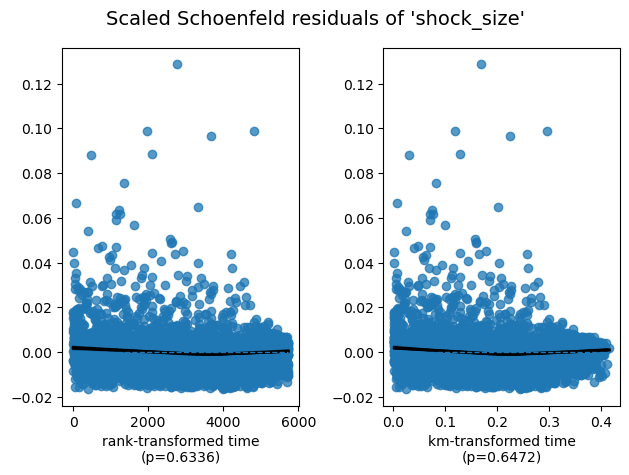

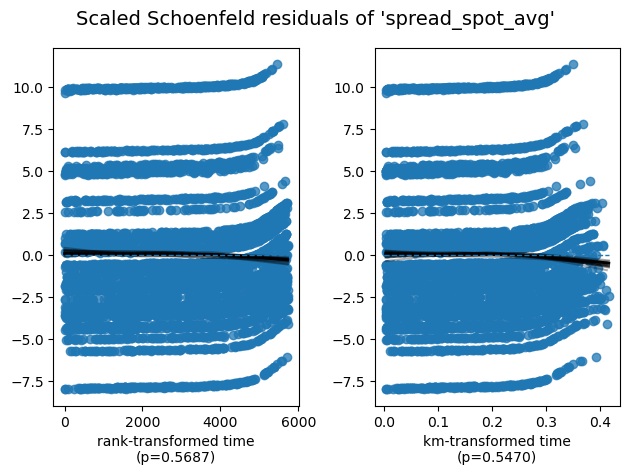

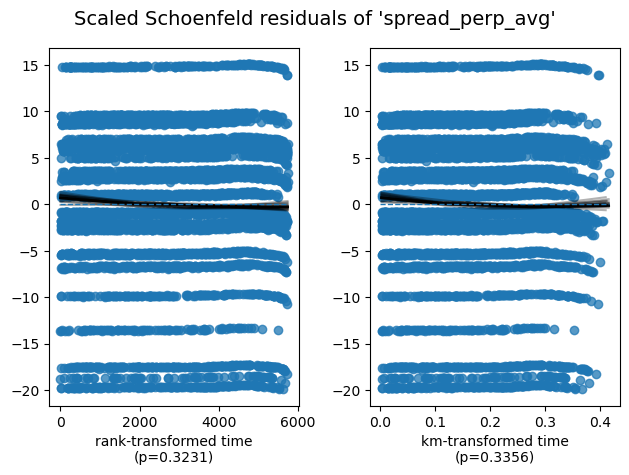

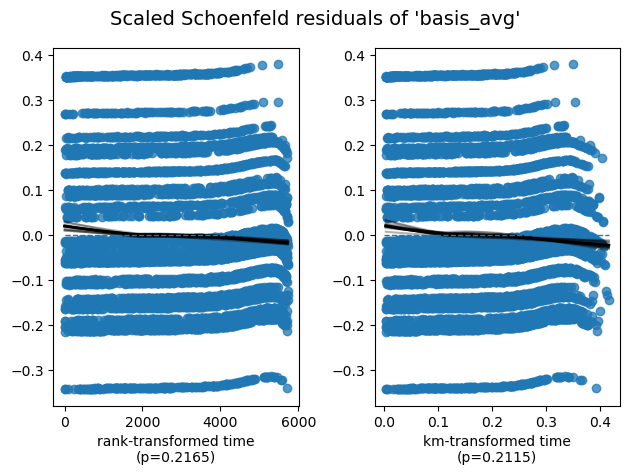

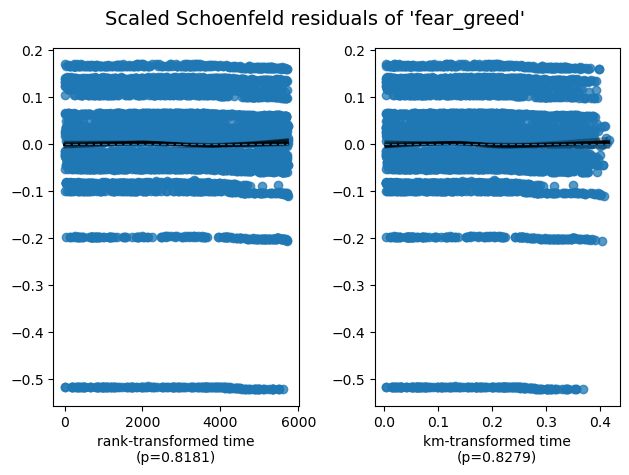

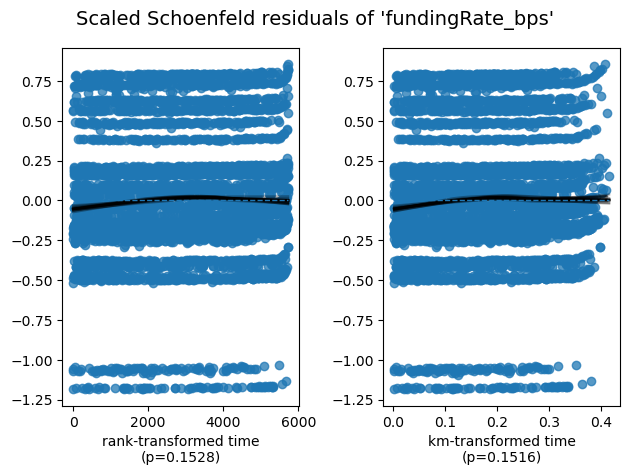

In [33]:
cph.check_assumptions(shocks_formatted.drop(['start_ts', 'fundingRate'], axis=1), show_plots=True)


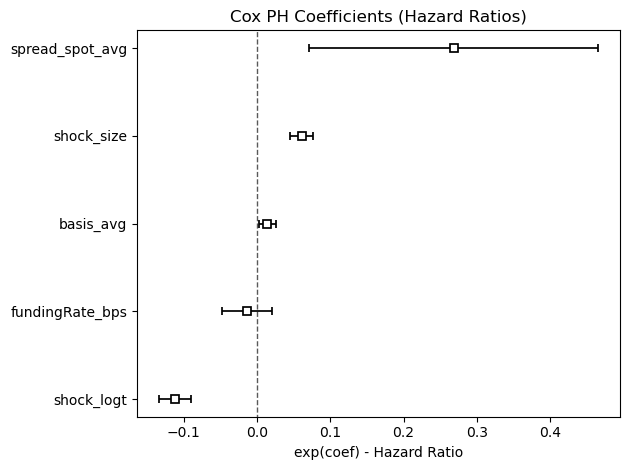

In [76]:
cph.plot()
plt.title('Cox PH Coefficients (Hazard Ratios)')
plt.xlabel('exp(coef) - Hazard Ratio')
plt.tight_layout()
plt.show()

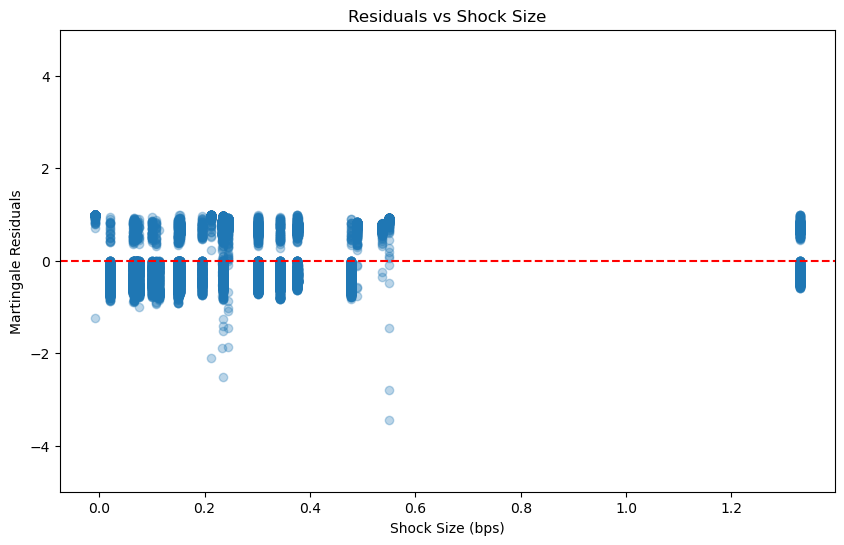

In [64]:
# Martingale residuals (should be randomly scattered around 0)
residuals = cph.compute_residuals(df, kind='martingale')

plt.figure(figsize=(10, 6))
plt.scatter(df['spread_spot_avg'], residuals['martingale'], alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Shock Size (bps)')
plt.ylabel('Martingale Residuals')
plt.title('Residuals vs Shock Size')
plt.ylim(-5,5)
plt.show()

,shock_size,spread_spot_avg,basis_avg,fundingRate_bps,shock_logt
0,1.91139,0.212657,10.977673,4.843167,0.208562


[]

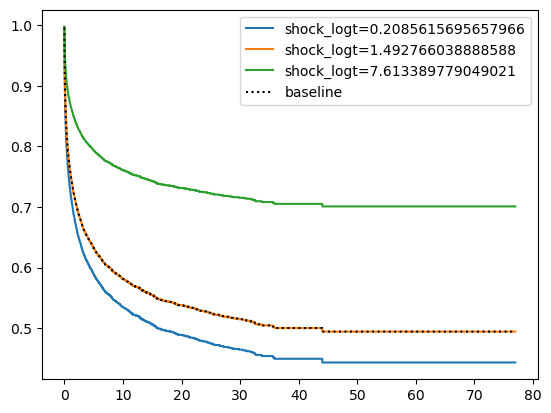

In [109]:

# Define groups (low, medium, high shock)
shock_groups = {
    'Low shock (25th)': df['shock_logt'].quantile(0.25),
    'Medium shock (50th)': df['shock_logt'].quantile(0.50),  
    'High shock (75th)': df['shock_logt'].quantile(0.75)
}

# for label, shock_val in shock_groups.items():
#     # Create scenario with this shock size, other vars at median
#     scenario = df[cph.params_.index].median().to_frame().T
#     scenario['shock_logt'] = shock_val
    
cph.plot_partial_effects_on_outcome(covariates='shock_logt', values=[df['shock_logt'].quantile(0.25),df['shock_logt'].quantile(0.5),df['shock_logt'].quantile(0.75)]).plot(ax=ax, label=label)

ICI =  0.023728855960856176
E50 =  0.024928693561615534


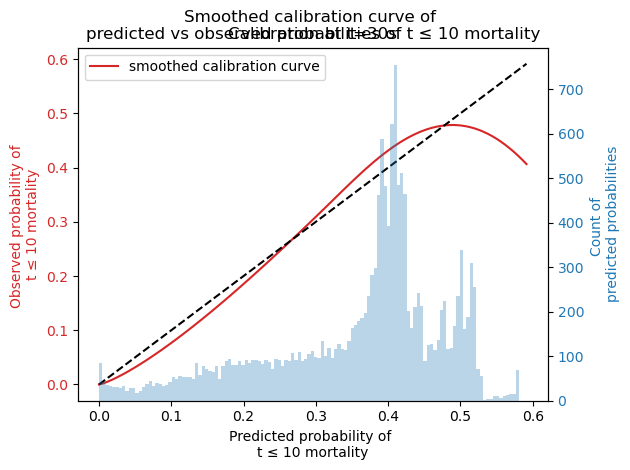

In [76]:
from lifelines.calibration import survival_probability_calibration

# Plot calibration
survival_probability_calibration(cph, df, t0=10)  # At 30 seconds
plt.title('Calibration at t=30s')
plt.show()

ICI =  0.11450647340818991
E50 =  0.08893773317578757


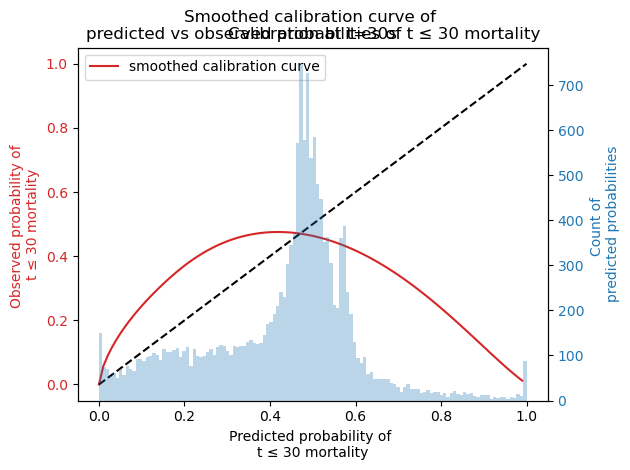

In [ ]:
from lifelines.calibration import survival_probability_calibration

# Plot calibration
survival_probability_calibration(cph, df, t0=10)  # At 30 seconds
plt.title('Calibration at t=30s')
plt.show()

### AFT Model

In [112]:
from lifelines import WeibullAFTFitter

# Fit exponential model
aft = WeibullAFTFitter()
aft.fit(df.drop('date', axis=1), duration_col='Length', event_col='Status')

aft.print_summary(3)  

<lifelines.WeibullAFTFitter: fitted with 16138 total observations, 10482 right-censored observations>
             duration col = 'Length'
                event col = 'Status'
   number of observations = 16138
number of events observed = 5656
           log-likelihood = -15486.220
         time fit was run = 2026-02-03 21:52:31 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                         
lambda_ basis_avg       -0.043     0.958     0.005          -0.053          -0.033               0.948               0.968
        fundingRate_bps  0.032     1.033     0.012           0.008           0.056               1.008               1.058
        shock_logt       0.284     1.328     0.007           0.269           0.298               1.309               1.348
        shock_size      -0.157     0.855     0.002          -0.161          -0.152               0.851               0.859
        spread_spot_avg -0.759     0.468     0.157          -1.067          -0.451               0.344               0.637
        Intercept        4.320    75.183     0.082           4.160           4.480              64.071              88.221
rho_    Intercept       -0.973     0.378     0.012          -0.997          -0.950               0.369               0.387

                         cmp to       z       p  -log2(p)
param   covariate                                        
lambda_ basis_avg         0.000  -8.174 <0.0005    51.576
        fundingRate_bps   0.000   2.588   0.010     6.693
        shock_logt        0.000  38.221 <0.0005       inf
        shock_size        0.000 -69.641 <0.0005       inf
        spread_spot_avg   0.000  -4.831 <0.0005    19.488
        Intercept         0.000  52.942 <0.0005       inf
rho_    Intercept         0.000 -82.436 <0.0005       inf
---
Concordance = 0.779
AIC = 30986.440
log-likelihood ratio test = 3613.390 on 5 df
-log2(p) of ll-ratio test = inf

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

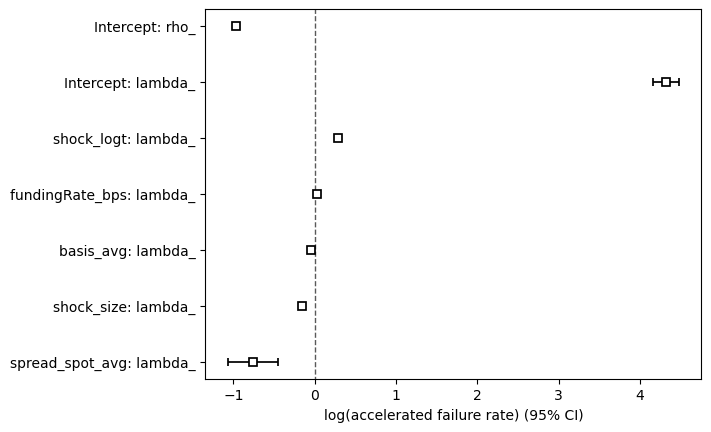

In [113]:
aft.plot()

Text(0.5, 1.0, 'Not modelling rho_')

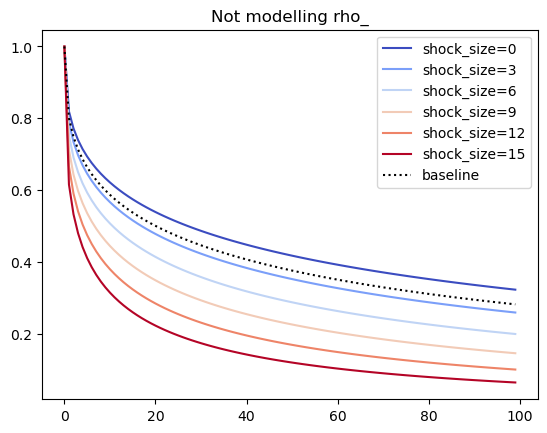

In [118]:
times = np.arange(0, 100)
wft_not_model_rho = WeibullAFTFitter().fit(df.drop('date', axis=1), duration_col='Length', event_col='Status', ancillary=False, timeline=times)
wft_not_model_rho.plot_partial_effects_on_outcome('shock_size', range(0, 16, 3), cmap='coolwarm')
plt.title("Not modelling rho_")

suspiciously good fit... drop?

In [122]:
from lifelines import LogNormalAFTFitter

aft_ln = LogNormalAFTFitter()
aft_ln.fit(df, "Length", "Status", formula="shock_size + shock_logt + spread_spot_avg + basis_avg + fundingRate_bps")
aft_ln.print_summary(3)

<lifelines.LogNormalAFTFitter: fitted with 16138 total observations, 10482 right-censored observations>
             duration col = 'Length'
                event col = 'Status'
   number of observations = 16138
number of events observed = 5656
           log-likelihood = -14435.310
         time fit was run = 2026-02-03 22:03:23 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                         
mu_    Intercept        3.222    25.081     0.078           3.070           3.374              21.545              29.198
       shock_size      -0.310     0.733     0.005          -0.320          -0.300               0.726               0.741
       shock_logt       0.361     1.435     0.006           0.349           0.374               1.417               1.454
       spread_spot_avg -0.512     0.599     0.151          -0.808          -0.217               0.446               0.805
       basis_avg       -0.014     0.986     0.005          -0.024          -0.004               0.976               0.996
       fundingRate_bps  0.019     1.019     0.012          -0.005           0.042               0.995               1.043
sigma_ Intercept        1.253     3.499     0.011           1.232           1.273               3.428               3.573

                        cmp to       z       p  -log2(p)
param  covariate                                        
mu_    Intercept         0.000  41.555 <0.0005       inf
       shock_size        0.000 -59.902 <0.0005       inf
       shock_logt        0.000  55.775 <0.0005       inf
       spread_spot_avg   0.000  -3.397   0.001    10.518
       basis_avg         0.000  -2.794   0.005     7.586
       fundingRate_bps   0.000   1.574   0.115     3.115
sigma_ Intercept         0.000 118.654 <0.0005       inf
---
Concordance = 0.841
AIC = 28884.620
log-likelihood ratio test = 4988.750 on 5 df
-log2(p) of ll-ratio test = inf

Text(0.5, 1.0, 'Not modelling rho_')

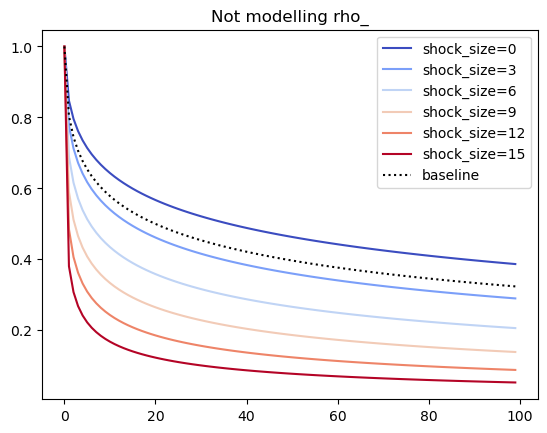

In [123]:
times = np.arange(0, 100)
wft_not_model_rho = LogNormalAFTFitter().fit(df.drop('date', axis=1), duration_col='Length', event_col='Status', ancillary=False, timeline=times)
wft_not_model_rho.plot_partial_effects_on_outcome('shock_size', range(0, 16, 3), cmap='coolwarm')
plt.title("Not modelling rho_")

### Testing on other data

Want to collect all the shocks, then fit different subsets of the data to different models

In [66]:
import datetime
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
from trade_data_pull import *
from survival_analysis import *

In [67]:
start = '20210101'
end = '20220101'

In [68]:
start_dt = datetime.datetime.strptime(start, '%Y%m%d')
end_dt = datetime.datetime.strptime(end, '%Y%m%d')

In [69]:
sa = SurvivalAnalysis('BTCUSDT')

In [70]:
curr_start_dt = end_dt - datetime.timedelta(days=30)
curr_end_dt = end_dt
collection = {}
save_csv=True 
while curr_start_dt >= start_dt:
    print(curr_start_dt)
    data_i, events_i, shocks_i = sa.fit_KM(datetime.datetime.strftime(curr_start_dt, '%Y%m%d'), datetime.datetime.strftime(curr_end_dt, '%Y%m%d'), [0.001])
    if save_csv:
        # events_i[0.001].to_csv(f'sa_results/events_{datetime.datetime.strftime(curr_start_dt, '%Y%m%d')}_{datetime.datetime.strftime(curr_end_dt, '%Y%m%d')}.csv')
        collection[curr_start_dt] = [data_i, events_i[0.001], shocks_i[0.001]['90%'].to_pandas()]
    
    curr_end_dt = curr_end_dt - datetime.timedelta(days=30)
    curr_start_dt = curr_end_dt - datetime.timedelta(days=30)

2021-12-02 00:00:00
Fetching file list from Binance...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Using cached file list...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
2021-11-02 00:00:00
Fetching file list from Binance...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Using cached file list...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
2021-10-03 00:00:00
Fetching file list from Binance...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Using cached file list...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
2021-09-03 00:00:00
Fetching file list from Binance...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Using cached file list...
Processing 31 files...
Processing batch 1/2
Processing batch 2/2
Combining

: 

In [ ]:
sa = SurvivalAnalysis('BTCUSDT')

data, events_sp, shocks_sp = sa.fit_KM('20210101', '20210201', [0.001])